# Core PCE Nowcast from CPI and PPI (Detailed Component Partition)

Estimates core PCE (PCE excluding food and energy) as soon as CPI (~mid-month) and
PPI (~1 day later) are released - about two weeks before the official PCE print.

Unlike `core_pce_nowcast.ipynb` (which works on the 178-component Dallas Fed
trimmed-mean partition), this version derives the **finest usable partition of the
full detailed PCE table** (`Detailed PCE.xlsx`, BEA table U20404, 368 lines):

1. The table's hierarchy is parsed from the workbook's indentation; `"Less:"` lines
   (nonresident spending, insurance normal losses, remittances) enter with negative
   sign, exactly as BEA nets them.
2. The partition uses the deepest level at which every component has complete BEA
   price and nominal data and children sum to their parent - about 219 components,
   covering total and core PCE **to the dollar** (the replication below matches the
   official index with ~0.03pp annualized error, corr 1.000).
3. Each component maps to the CPI/PPI series BEA uses as its deflator: the validated
   trimmed-mean crosswalk, inherited down the hierarchy, plus refinements the extra
   detail makes possible (portfolio management vs brokerage commissions, insurance
   premiums vs normal losses, wireless vs landline, limited- vs full-service meals,
   home health vs medical labs). Components with no timely source use the trailing
   6-month average of their own BEA change.
4. Component changes are aggregated with signed expenditure weights (prior month's,
   renormalized within core) and backtested monthly from 2015 against the official
   core PCE price index (FRED `PCEPILFE`).

Data sources: BLS API v2 (CPI/PPI), BEA API (underlying detail tables
U20404/U20405/U20406), FRED (official core PCE).

In [1]:
import json
import time
import urllib.parse
import urllib.request
from datetime import date
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BLS_API_KEY = "52fd9616f3bc44a3878d8416229082ca"
FRED_API_KEY = "51f3ac7bc8b65cb6bb2589fc570292be"
BEA_API_KEY = "FD4E7F46-5D89-4CA8-BE48-4F5997F83B3B"

BASE_DIR = Path.cwd()
DETAIL_FILE = BASE_DIR / "Detailed PCE.xlsx"
OUTPUT_DIR = BASE_DIR / "outputs"

BACKTEST_START = pd.Timestamp("2015-01-01")  # first backtest month
SOURCE_START_YEAR = 2009  # CPI/PPI pull start (5y history feeds the crude SA)
BEA_START_YEAR = 2013     # BEA pull start (weights, fallbacks, backtest actuals)
CRUDE_SA = True           # crude own-history seasonal adjustment of NSA CPI (CUUR) series

## 1. Detailed PCE Hierarchy

The workbook lists all 368 lines of BEA table 2.4.4U with the tree encoded in the
description indentation. `"Less:"` lines and their descendants carry a negative sign
(they are netted out of their parent, e.g. nonresident spending inside net foreign
travel, insurance normal losses inside net household insurance).

In [2]:
det = pd.read_excel(DETAIL_FILE, usecols=[0, 1, 2], dtype={1: str})
det.columns = ["line", "desc", "code"]
det = det.dropna(subset=["line"]).copy()
det["line"] = det["line"].astype(int)
det["indent"] = det["desc"].str.len() - det["desc"].str.lstrip().str.len()
det["desc"] = det["desc"].str.strip()
det = det.set_index("line").sort_index()
det.loc[1, "indent"] = -1  # title row is center-padded in the workbook
descriptions = det["desc"]

parent = {}
stack = []
for L, row in det.iterrows():
    while stack and stack[-1][1] >= row["indent"]:
        stack.pop()
    parent[L] = stack[-1][0] if stack else None
    stack.append((L, row["indent"]))
children = {}
for L, p in parent.items():
    children.setdefault(p, []).append(L)


def ancestors(L):
    out = []
    p = parent.get(L)
    while p is not None:
        out.append(p)
        p = parent.get(p)
    return out


def descendants(L):
    out = set()
    for k in children.get(L, []):
        out.add(k)
        out |= descendants(k)
    return out


sign = {L: (-1) ** sum(descriptions[a].startswith("Less:")
                       for a in [L] + ancestors(L)) for L in det.index}
print(f"{len(det)} lines, {sum(1 for s in sign.values() if s < 0)} with negative sign")

368 lines, 19 with negative sign


## 2. Fetch Helpers

In [3]:
def bls_fetch(series_ids, start_year, end_year):
    """Fetch monthly BLS series (chunks of 50). Returns wide DataFrame + missing ids."""
    frames = {}
    series_ids = list(series_ids)
    for i in range(0, len(series_ids), 50):
        chunk = series_ids[i:i + 50]
        payload = json.dumps({
            "seriesid": chunk,
            "startyear": str(start_year),
            "endyear": str(end_year),
            "registrationkey": BLS_API_KEY,
        }).encode()
        req = urllib.request.Request(
            "https://api.bls.gov/publicAPI/v2/timeseries/data/",
            data=payload, headers={"Content-Type": "application/json"})
        with urllib.request.urlopen(req, timeout=120) as resp:
            out = json.loads(resp.read())
        if out.get("status") != "REQUEST_SUCCEEDED":
            raise RuntimeError(f"BLS API: {out.get('status')} {out.get('message')}")
        for s in out["Results"]["series"]:
            rows = {
                pd.Timestamp(int(r["year"]), int(r["period"][1:]), 1): float(r["value"])
                for r in s["data"]
                if r["period"].startswith("M") and r["period"] != "M13"
                and r["value"] not in ("-", "")
            }
            if rows:
                frames[s["seriesID"]] = pd.Series(rows)
        time.sleep(0.2)
    df = pd.DataFrame(frames).sort_index()
    missing = [sid for sid in series_ids if sid not in df.columns]
    return df, missing


def fred_fetch(series_id, start="2009-01-01"):
    """Fetch one FRED series as a monthly Series."""
    url = ("https://api.stlouisfed.org/fred/series/observations"
           f"?series_id={series_id}&api_key={FRED_API_KEY}&file_type=json"
           f"&observation_start={start}")
    with urllib.request.urlopen(url, timeout=60) as resp:
        obs = json.loads(resp.read())["observations"]
    return pd.Series({pd.Timestamp(o["date"]): float(o["value"])
                      for o in obs if o["value"] != "."})

## 3. BEA Underlying Detail Tables

All lines of prices (U20404), nominal (U20405), and real (U20406) from 2013 on.
These drive the partition choice, the expenditure weights, the trailing-average
fallback, and the actual component changes the nowcast is scored against.

In [4]:
BEA_TABLES = {"prices": "U20404", "nominal": "U20405", "real": "U20406"}
matrices = {}

for label, table_name in BEA_TABLES.items():
    rows = []
    for year in range(BEA_START_YEAR, date.today().year + 1):
        params = {
            "UserID": BEA_API_KEY, "method": "GetData",
            "DataSetName": "NIUnderlyingDetail", "TableName": table_name,
            "Frequency": "M", "Year": str(year), "ResultFormat": "JSON",
        }
        url = "https://apps.bea.gov/api/data?" + urllib.parse.urlencode(params)
        with urllib.request.urlopen(url, timeout=120) as response:
            payload = json.loads(response.read().decode("utf-8-sig"))
        if payload.get("BEAAPI", {}).get("Error"):
            continue
        data = payload["BEAAPI"]["Results"].get("Data", [])
        rows.extend([data] if isinstance(data, dict) else data)
        time.sleep(0.1)

    df = pd.DataFrame(rows)
    df["line"] = pd.to_numeric(df["LineNumber"], errors="coerce")
    df["date"] = pd.to_datetime(df["TimePeriod"].astype(str).str.replace(
        r"^(\d{4})M(\d{1,2})$", r"\1-\2-01", regex=True))
    df["value"] = pd.to_numeric(
        df["DataValue"].astype(str).str.replace(",", ""), errors="coerce")
    matrix = (df.dropna(subset=["line"])
              .pivot_table(index="date", columns="line", values="value",
                           aggfunc="first").sort_index())
    matrix.columns = matrix.columns.astype(int)
    matrices[label] = matrix
    print(f"{table_name} ({label}): {matrix.shape[0]} months x {matrix.shape[1]} lines")

U20404 (prices): 161 months x 398 lines


U20405 (nominal): 161 months x 400 lines


U20406 (real): 161 months x 400 lines


## 4. Finest Usable Partition

Starting from total PCE, each aggregate is replaced by its children whenever every
child (or its own subtree) has complete price and nominal data and the children's
signed nominal spending sums to the parent. Expansion stops deliberately at used
autos/trucks (13/17: net-transaction and margin sublines share one source) and NPISH
final consumption (342: entirely imputed). Food and energy are then removed: all
descendants of line 73 (food and beverages purchased for off-premises consumption)
and line 113 (gasoline and other energy goods), plus 170/171 (electricity, natural
gas). Coverage of official core PCE is exact.

In [5]:
STOP_AT = {13, 17, 342}
LAST12 = matrices["nominal"].index[-12:]


def snom(L):
    """Signed nominal spending, averaged over the last 12 months."""
    return sign[L] * matrices["nominal"][L].reindex(LAST12).mean()


def usable(L):
    if L not in matrices["prices"].columns or L not in matrices["nominal"].columns:
        return False
    return (matrices["prices"][L].notna().mean() > 0.99
            and matrices["nominal"][L].notna().mean() > 0.99)


def expand(L):
    kids = children.get(L, [])
    if not kids or L in STOP_AT:
        return [L] if usable(L) else []
    if all(usable(k) or children.get(k) for k in kids):
        out = []
        for k in kids:
            e = expand(k)
            if not e:
                break
            out.extend(e)
        else:
            if abs(sum(snom(c) for c in out) - snom(L)) < max(2.0, 0.002 * abs(snom(L))):
                return out
    return [L] if usable(L) else []


partition = expand(1)
core_excl = descendants(73) | {73} | descendants(113) | {113} | {170, 171}
core_lines = sorted(set(partition) - core_excl)

official_core = snom(1) - snom(73) - snom(113) - snom(170) - snom(171)
core_cov = sum(snom(L) for L in core_lines)
print(f"partition: {len(partition)} components, core: {len(core_lines)}")
print(f"core coverage: {core_cov:,.0f} of official {official_core:,.0f} "
      f"({100 * core_cov / official_core:.2f}%)")
neg = [L for L in core_lines if snom(L) < 0]
print(f"negative-weight components: {len(neg)} (nonresident spending, insurance "
      f"losses, remittances, employee reimbursement)")

partition: 219 components, core: 191
core coverage: 19,089,801 of official 19,089,799 (100.00%)
negative-weight components: 5 (nonresident spending, insurance losses, remittances, employee reimbursement)


## 5. CPI/PPI Crosswalk

Base mapping = the validated trimmed-mean crosswalk (`CROSSWALK`, by BEA line).
Components finer than that partition inherit their nearest mapped ancestor's series,
except where the extra detail allows a better source (`OVERRIDES`): portfolio
management vs brokerage commissions, insurance premiums vs normal losses (losses ->
fallback), wireless vs landline telephone, postal vs delivery, limited- vs
full-service meals, home health vs medical laboratories, audio streaming. In
addition, the four PPIs with a BLS-published seasonally adjusted commodity variant
(physician care, hospital inpatient care, nursing homes, airline passenger services)
use the `WPS...` series instead of the NSA industry `PCU...` codes. Overrides were
validated against actual BEA component changes; candidates that fit worse than the
trailing-average fallback (bank service charges, foreign passenger fares) are
mapped `NONE`.

In [6]:
CROSSWALK = {
    # --- Motor vehicles and parts ---
    7:   ("CPI", {"CUSR0000SETA01": 1.0}),   # New domestic autos -> new vehicles
    8:   ("CPI", {"CUSR0000SETA01": 1.0}),   # New foreign autos -> new vehicles
    9:   ("CPI", {"CUSR0000SS45021": 1.0}),  # New light trucks -> new trucks
    13:  ("CPI", {"CUSR0000SETA02": 1.0}),   # Used autos -> used cars and trucks
    17:  ("CPI", {"CUSR0000SETA02": 1.0}),   # Used light trucks
    21:  ("CPI", {"CUSR0000SETC01": 1.0}),   # Tires
    22:  ("CPI", {"CUUR0000SETC02": 1.0}),   # Accessories and parts
    # --- Furnishings and durable household equipment ---
    25:  ("CPI", {"CUSR0000SEHJ": 1.0}),     # Furniture -> furniture and bedding
    26:  ("CPI", {"CUUR0000SEHL01": 1.0}),   # Clocks, lamps, decorator items
    27:  ("CPI", {"CUUR0000SEHH01": 1.0}),   # Carpets -> floor coverings
    28:  ("CPI", {"CUSR0000SEHH02": 1.0}),   # Window coverings
    30:  ("CPI", {"CUSR0000SEHK01": 1.0}),   # Major household appliances
    31:  ("CPI", {"CUSR0000SEHK02": 1.0}),   # Small electric appliances -> other appliances
    33:  ("NONE", {}),                       # Dishes and flatware (fallback fits better)
    34:  ("NONE", {}),                       # Nonelectric cookware (fallback fits better)
    36:  ("CPI", {"CUSR0000SEHM01": 1.0}),   # Tools, hardware and supplies
    37:  ("CPI", {"CUSR0000SEHM02": 1.0}),   # Outdoor equipment and supplies
    # --- Recreational goods and vehicles ---
    41:  ("CPI", {"CUSR0000SERA01": 1.0}),   # Televisions
    42:  ("CPI", {"CUSR0000SERA03": 1.0}),   # Other video equipment
    43:  ("CPI", {"CUSR0000SERA05": 1.0}),   # Audio equipment
    45:  ("CPI", {"CUUR0000SERA06": 1.0}),   # Audio media -> recorded music
    46:  ("CPI", {"CUUR0000SERA04": 1.0}),   # Video media
    47:  ("CPI", {"CUSR0000SERD01": 1.0}),   # Photographic equipment
    49:  ("CPI", {"CUSR0000SEEE01": 1.0}),   # Personal computers and peripherals
    50:  ("CPI", {"CUUR0000SEEE02": 1.0}),   # Computer software and accessories
    51:  ("CPI", {"CUSR0000SEEE04": 1.0}),   # Calculators/other info processing
    52:  ("CPI", {"CUSR0000SERC02": 1.0}),   # Sporting equipment -> sports equipment
    54:  ("CPI", {"CUSR0000SERC01": 1.0}),   # Motorcycles -> sports vehicles incl bicycles
    55:  ("CPI", {"CUSR0000SERC01": 1.0}),   # Bicycles
    57:  ("CPI", {"CUSR0000SERC01": 1.0}),   # Pleasure boats
    58:  ("CPI", {"CUSR0000SERC01": 1.0}),   # Pleasure aircraft
    59:  ("CPI", {"CUSR0000SERC01": 1.0}),   # Other recreational vehicles
    60:  ("CPI", {"CUUR0000SERG02": 1.0}),   # Recreational books
    61:  ("CPI", {"CUSR0000SERE03": 1.0}),   # Musical instruments
    64:  ("CPI", {"CUSR0000SEAG02": 1.0}),   # Jewelry
    65:  ("CPI", {"CUSR0000SEAG01": 1.0}),   # Watches
    # --- Other durable goods ---
    67:  ("CPI", {"CUUR0000SEMG": 1.0}),     # Therapeutic medical equipment
    68:  ("CPI", {"CUSR0000SEMC04": 1.0}),   # Eyeglasses and eye care
    69:  ("CPI", {"CUSR0000SEEA": 1.0}),     # Educational books and supplies
    70:  ("CPI", {"CUSR0000SEGE": 1.0}),     # Luggage -> misc personal goods
    71:  ("CPI", {"CUSR0000SEEE04": 1.0}),   # Telephone equipment
    # --- Food at home ---
    77:  ("CPI", {"CUSR0000SEFA": 1.0}),     # Cereals
    78:  ("CPI", {"CUSR0000SEFB": 1.0}),     # Bakery products
    80:  ("CPI", {"CUSR0000SEFC": 1.0}),     # Beef and veal
    81:  ("CPI", {"CUSR0000SEFD": 1.0}),     # Pork
    82:  ("CPI", {"CUSR0000SEFE": 1.0}),     # Other meats
    83:  ("CPI", {"CUSR0000SEFF": 1.0}),     # Poultry
    84:  ("CPI", {"CUSR0000SEFG": 1.0}),     # Fish and seafood
    86:  ("CPI", {"CUSR0000SEFJ01": 1.0}),   # Fresh milk -> milk
    87:  ("CPI", {"CUSR0000SEFJ": 1.0}),     # Processed dairy -> dairy products
    88:  ("CPI", {"CUSR0000SEFH": 1.0}),     # Eggs
    89:  ("CPI", {"CUSR0000SEFS": 1.0}),     # Fats and oils
    91:  ("CPI", {"CUSR0000SEFK": 1.0}),     # Fresh fruit
    92:  ("CPI", {"CUSR0000SEFL": 1.0}),     # Fresh vegetables
    93:  ("CPI", {"CUSR0000SEFM": 1.0}),     # Processed fruits and vegetables
    94:  ("CPI", {"CUSR0000SEFR": 1.0}),     # Sugar and sweets
    95:  ("CPI", {"CUSR0000SEFT": 1.0}),     # Food nec -> other foods
    97:  ("CPI", {"CUSR0000SEFP": 1.0}),     # Coffee, tea -> beverage materials
    98:  ("CPI", {"CUSR0000SEFN": 1.0}),     # Soft drinks -> nonalcoholic beverages
    100: ("CPI", {"CUSR0000SEFW02": 1.0}),   # Spirits at home
    101: ("CPI", {"CUSR0000SEFW03": 1.0}),   # Wine at home
    102: ("CPI", {"CUSR0000SEFW01": 1.0}),   # Beer at home
    103: ("NONE", {}),                       # Food produced/consumed on farms
    # --- Clothing and footwear ---
    106: ("CPI", {"CUSR0000SEAC": 1.0}),     # Women's and girls'
    107: ("CPI", {"CUSR0000SEAA": 1.0}),     # Men's and boys'
    108: ("CPI", {"CUSR0000SEAF": 1.0}),     # Children's and infants'
    110: ("NONE", {}),                       # Clothing materials (no live CPI series)
    111: ("NONE", {}),                       # Military clothing
    112: ("CPI", {"CUSR0000SEAE": 1.0}),     # Footwear
    # --- Energy goods ---
    115: ("CPI", {"CUSR0000SETB01": 1.0}),   # Gasoline
    116: ("CPI", {"CUUR0000SS47021": 1.0}),  # Lubricants -> motor oil, coolant
    118: ("CPI", {"CUSR0000SEHE01": 1.0}),   # Fuel oil
    119: ("CPI", {"CUSR0000SEHE02": 1.0}),   # Other fuels -> propane, kerosene, firewood
    # --- Medical goods ---
    123: ("CPI", {"CUSR0000SEMF01": 1.0}),   # Prescription drugs
    124: ("CPI", {"CUSR0000SEMF02": 1.0}),   # Nonprescription drugs
    125: ("CPI", {"CUUR0000SEMG": 1.0}),     # Other medical products
    # --- Other nondurable goods ---
    127: ("CPI", {"CUSR0000SERE01": 1.0}),   # Games, toys -> toys
    128: ("CPI", {"CUSR0000SERB01": 1.0}),   # Pets and related products
    129: ("CPI", {"CUSR0000SEHL02": 1.0}),   # Flowers, seeds, potted plants
    130: ("CPI", {"CUUR0000SERD02": 1.0}),   # Film and photographic supplies
    132: ("CPI", {"CUSR0000SEHN01": 1.0}),   # Household cleaning products
    133: ("CPI", {"CUUR0000SEHN02": 1.0}),   # Household paper products
    134: ("CPI", {"CUSR0000SEHH03": 1.0}),   # Household linens -> other linens
    135: ("NONE", {}),                       # Sewing items (no live CPI series)
    136: ("CPI", {"CUSR0000SEHN03": 1.0}),   # Misc household products
    138: ("CPI", {"CUUR0000SEGB01": 1.0}),   # Hair/dental/shaving products
    139: ("CPI", {"CUUR0000SEGB02": 1.0}),   # Cosmetics
    140: ("NONE", {}),                       # Electric personal care (fallback fits better)
    141: ("CPI", {"CUSR0000SEGA": 1.0}),     # Tobacco
    143: ("CPI", {"CUUR0000SERG01": 1.0}),   # Newspapers and periodicals
    144: ("CPI", {"CUSR0000SEGE": 1.0}),     # Stationery -> misc personal goods
    # --- Housing ---
    155: ("CPI", {"CUSR0000SEHA": 1.0}),     # Tenant mobile homes -> rent
    157: ("CPI", {"CUSR0000SEHA": 1.0}),     # Tenant stationary homes -> rent
    158: ("CPI", {"CUSR0000SEHA": 1.0}),     # Tenant landlord durables -> rent
    161: ("CPI", {"CUSR0000SEHC": 1.0}),     # Owner mobile homes -> OER
    162: ("CPI", {"CUSR0000SEHC": 1.0}),     # Owner stationary homes -> OER
    163: ("NONE", {}),                       # Farm dwellings
    164: ("NONE", {}),                       # Group housing
    # --- Household utilities ---
    167: ("CPI", {"CUSR0000SEHG01": 1.0}),   # Water and sewer
    168: ("CPI", {"CUSR0000SEHG02": 1.0}),   # Garbage and trash
    170: ("CPI", {"CUSR0000SEHF01": 1.0}),   # Electricity
    171: ("CPI", {"CUSR0000SEHF02": 1.0}),   # Natural gas
    # --- Health care services (PPI per BEA methodology) ---
    174: ("PPI", {"PCU621111621111": 1.0}),  # Physician services
    175: ("CPI", {"CUSR0000SEMC02": 1.0}),   # Dental services (CPI fits BEA best)
    176: ("PPI", {"PCU621610621610": 0.5,    # Paramedical: home health
                  "PCU621511621511": 0.5}),  #   + medical labs
    184: ("PPI", {"PCU622110622110": 1.0}),  # Nonprofit hospitals
    185: ("PPI", {"PCU622110622110": 1.0}),  # Proprietary hospitals
    186: ("PPI", {"PCU622110622110": 1.0}),  # Government hospitals
    187: ("PPI", {"PCU623110623110": 1.0}),  # Nursing homes
    # --- Transportation services ---
    192: ("CPI", {"CUSR0000SETD": 1.0}),     # Motor vehicle maintenance/repair
    194: ("CPI", {"CUSR0000SETA03": 1.0}),   # Motor vehicle leasing -> leased cars
    197: ("CPI", {"CUSR0000SETA04": 1.0}),   # Motor vehicle rental -> car rental
    198: ("CPI", {"CUSR0000SS52051": 1.0}),  # Parking fees and tolls
    201: ("CPI", {"CUSR0000SETG02": 1.0}),   # Railway -> other intercity transport
    203: ("CPI", {"CUSR0000SETG02": 1.0}),   # Intercity buses
    204: ("NONE", {}),                       # Taxis (CPI series ended 2019)
    205: ("CPI", {"CUUR0000SETG03": 1.0}),   # Intracity mass transit
    206: ("NONE", {}),                       # Other road transportation
    207: ("PPI", {"PCU481111481111": 1.0}),  # Air transportation (PPI per BEA)
    208: ("CPI", {"CUSR0000SS53023": 1.0}),  # Water transportation -> ship fare
    # --- Recreation services ---
    211: ("CPI", {"CUSR0000SERF01": 1.0}),   # Membership clubs, sports centers
    212: ("CPI", {"CUSR0000SERF02": 1.0}),   # Amusement parks -> admissions
    214: ("CPI", {"CUSR0000SS62031": 1.0}),  # Movie theaters
    215: ("CPI", {"CUSR0000SS62031": 1.0}),  # Live entertainment
    216: ("NONE", {}),                       # Spectator sports (fallback fits better)
    217: ("NONE", {}),                       # Museums and libraries
    218: ("CPI", {"CUSR0000SERA02": 1.0}),   # AV services -> cable/satellite/streaming
    227: ("NONE", {}),                       # Casino gambling
    228: ("NONE", {}),                       # Lotteries
    229: ("NONE", {}),                       # Pari-mutuel
    231: ("CPI", {"CUSR0000SERB02": 1.0}),   # Veterinary and pet services
    232: ("NONE", {}),                       # Package tours
    233: ("NONE", {}),                       # Repair of rec vehicles/equipment
    # --- Food services and accommodations ---
    239: ("NONE", {}),                       # Elem/secondary school lunches (no CPI fit)
    240: ("NONE", {}),                       # Higher ed school lunches (no CPI fit)
    241: ("CPI", {"CUSR0000SEFV": 1.0}),     # Other purchased meals -> food away
    245: ("CPI", {"CUSR0000SEFX": 1.0}),     # Alcohol in purchased meals
    247: ("NONE", {}),                       # Food supplied to civilians
    248: ("NONE", {}),                       # Food supplied to military
    250: ("CPI", {"CUSR0000SEHB02": 1.0}),   # Hotels and motels
    251: ("CPI", {"CUSR0000SEHB01": 1.0}),   # Housing at schools
    # --- Financial services and insurance ---
    255: ("NONE", {}),                       # Commercial banks (imputed)
    256: ("NONE", {}),                       # Other depository (imputed)
    257: ("NONE", {}),                       # Pension funds (imputed)
    258: ("PPI", {"PCU5239405239401": 0.6,   # Financial charges: portfolio mgmt
                  "WPU40110101": 0.4}),      #   + brokerage/investment advice PPI
    271: ("NONE", {}),                       # Life insurance (imputed)
    272: ("PPI", {"PCU9241269241262": 1.0}), # Household insurance -> homeowners PPI
    275: ("PPI", {"PCU524114524114": 1.0}),  # Health insurance -> direct health PPI
    279: ("PPI", {"PCU9241269241261": 1.0}), # Motor vehicle insurance -> auto PPI
    # --- Communication ---
    281: ("CPI", {"CUUR0000SEED": 0.6,       # Telephone services
                  "CUSR0000SEEE03": 0.3,     # Internet services
                  "CUSR0000SEEC01": 0.1}),   # Postage
    # --- Education ---
    292: ("CPI", {"CUSR0000SEEB01": 1.0}),   # Public/proprietary higher ed -> college tuition
    293: ("CPI", {"CUSR0000SEEB01": 1.0}),   # Nonprofit higher ed
    295: ("CPI", {"CUSR0000SEEB02": 1.0}),   # Elementary and secondary schools
    296: ("CPI", {"CUSR0000SEEB03": 1.0}),   # Day care and nursery -> day care/preschool
    297: ("CPI", {"CUSR0000SEEB04": 1.0}),   # Commercial/vocational schools
    # --- Professional and personal services ---
    299: ("CPI", {"CUSR0000SEGD01": 1.0}),   # Legal services (ends 2025 -> fallback)
    301: ("NONE", {}),                       # Tax preparation (fallback fits better)
    302: ("NONE", {}),                       # Employment agency services
    303: ("NONE", {}),                       # Other personal business services
    304: ("NONE", {}),                       # Labor organization dues
    305: ("NONE", {}),                       # Professional association dues
    306: ("CPI", {"CUSR0000SEGD02": 1.0}),   # Funeral and burial
    309: ("CPI", {"CUUR0000SEGC01": 1.0}),   # Hairdressing -> haircuts
    310: ("CPI", {"CUUR0000SEGC": 1.0}),     # Misc personal care services
    312: ("CPI", {"CUSR0000SEGD03": 1.0}),   # Laundry and dry cleaning
    313: ("CPI", {"CUUR0000SEGD04": 1.0}),   # Clothing repair/rental
    314: ("CPI", {"CUUR0000SEGD04": 1.0}),   # Footwear repair
    316: ("CPI", {"CUSR0000SEEB03": 1.0}),   # Child care -> day care/preschool
    317: ("NONE", {}),                       # Social assistance
    324: ("NONE", {}),                       # Social advocacy orgs
    325: ("NONE", {}),                       # Religious organizations
    326: ("NONE", {}),                       # Foundations
    # --- Household services ---
    328: ("CPI", {"CUUR0000SEHP01": 1.0}),   # Domestic services (ends 2025 -> fallback)
    329: ("CPI", {"CUSR0000SEHP03": 1.0}),   # Moving, storage, freight
    330: ("CPI", {"CUUR0000SEHP04": 1.0}),   # Repair of furniture (ends 2025)
    331: ("CPI", {"CUUR0000SEHP04": 1.0}),   # Repair of appliances (ends 2025)
    332: ("NONE", {}),                       # Other household services
    # --- NPISH ---
    342: ("NONE", {}),                       # NPISH final consumption (imputed)
}


OVERRIDES = {
    # BLS-published seasonally adjusted commodity PPIs (WPS...) replace the NSA
    # industry PPIs where they exist - BLS's own factors beat the crude adjustment.
    174: ("PPI", {"WPS511101": 1.0}),         # physician care, SA
    184: ("PPI", {"WPS512101": 1.0}),         # hospital inpatient care, SA
    185: ("PPI", {"WPS512101": 1.0}),
    186: ("PPI", {"WPS512101": 1.0}),
    187: ("PPI", {"WPS512102": 1.0}),         # nursing home care, SA
    188: ("PPI", {"WPS512102": 1.0}),
    189: ("PPI", {"WPS512102": 1.0}),
    207: ("PPI", {"WPS302201": 1.0}),         # airline passenger services, SA
    177: ("PPI", {"PCU621610621610": 1.0}),   # home health care
    178: ("PPI", {"PCU621511621511": 1.0}),   # medical laboratories
    220: ("NONE", {}),                        # photo processing
    221: ("NONE", {}),                        # photo studios
    222: ("NONE", {}),                        # repair/rental of AV equipment
    225: ("CPI", {"CUUR0000SERA06": 1.0}),    # audio streaming -> recorded music/subscr
    242: ("CPI", {"CUUR0000SEFV02": 1.0}),    # limited service meals
    243: ("CPI", {"CUSR0000SEFV01": 1.0}),    # meals at other eating places -> full service
    259: ("NONE", {}),                        # bank service charges (checking CPI fits poorly)
    262: ("PPI", {"WPU40110101": 1.0}),       # exchange-listed equities -> brokerage
    263: ("PPI", {"WPU40110101": 1.0}),       # other direct commissions
    265: ("PPI", {"WPU40110101": 1.0}),       # OTC equities (imputed commissions)
    266: ("PPI", {"WPU40110101": 1.0}),       # other imputed commissions
    267: ("PPI", {"WPU40110101": 1.0}),       # mutual fund sales charges
    268: ("PPI", {"PCU5239405239401": 1.0}),  # portfolio management and inv advice
    269: ("PPI", {"PCU5239405239401": 1.0}),  # trust, fiduciary, custody
    273: ("PPI", {"PCU9241269241262": 1.0}),  # household insurance premiums
    274: ("NONE", {}),                        # less: household insurance normal losses
    276: ("PPI", {"PCU524114524114": 1.0}),   # health ins: medical & hospitalization
    277: ("NONE", {}),                        # health ins: income loss
    278: ("NONE", {}),                        # workers' compensation
    283: ("CPI", {"CUUR0000SEED": 1.0}),      # landline local (no separate CPI)
    284: ("CPI", {"CUUR0000SEED": 1.0}),      # landline long-distance
    285: ("CPI", {"CUUR0000SEED03": 1.0}),    # cellular -> wireless CPI
    287: ("CPI", {"CUSR0000SEEC01": 1.0}),    # first-class postal -> postage
    288: ("CPI", {"CUUR0000SEEC02": 1.0}),    # other delivery services
    289: ("CPI", {"CUSR0000SEEE03": 1.0}),    # internet access
    335: ("NONE", {}),                        # foreign passenger fares (air PPI fits poorly)
    336: ("NONE", {}), 337: ("NONE", {}),     # travel/study abroad
    339: ("NONE", {}), 340: ("NONE", {}), 341: ("NONE", {}),  # nonresident spending
    147: ("NONE", {}), 148: ("NONE", {}), 149: ("NONE", {}),  # net expenditures abroad
    156: ("CPI", {"CUSR0000SEHA": 1.0}),      # tenant stationary homes -> rent
}

XWALK = {}
for L in partition:
    if L in OVERRIDES:
        XWALK[L] = OVERRIDES[L]
    elif L in CROSSWALK:
        XWALK[L] = CROSSWALK[L]
    else:
        a = next((a for a in ancestors(L) if a in CROSSWALK), None)
        if a is not None:
            XWALK[L] = CROSSWALK[a]        # inherit the parent component's source
        else:
            d = sorted(descendants(L) & set(CROSSWALK))
            assert d, f"no mapping found for line {L}"
            XWALK[L] = CROSSWALK[d[0]]     # e.g. 156 <- 157 (rent)

n_none = sum(1 for L in core_lines if XWALK[L][0] == "NONE")
print(f"{len(core_lines)} core components: {len(core_lines) - n_none} mapped to "
      f"CPI/PPI, {n_none} on fallback")

191 core components: 134 mapped to CPI/PPI, 57 on fallback


## 6. Pull CPI/PPI Source Data

Only series mapped to core components. BLS first; anything missing is retried on
FRED (same mnemonics). Missing/discontinued series fall to the fallback rule.

In [7]:
all_series = sorted({sid for L in core_lines for sid in XWALK[L][1]})
source_levels, missing_series = bls_fetch(all_series, SOURCE_START_YEAR, date.today().year)

for sid in list(missing_series):
    try:
        s = fred_fetch(sid)
        if len(s):
            source_levels[sid] = s
            missing_series.remove(sid)
            print(f"{sid}: recovered from FRED")
    except Exception:
        pass
source_levels = source_levels.sort_index()

print(f"pulled {source_levels.shape[1]} of {len(all_series)} series, "
      f"{source_levels.index[0]:%Y-%m} .. {source_levels.index[-1]:%Y-%m}")
if missing_series:
    print("STILL MISSING (will use fallback):", missing_series)

report = pd.DataFrame({
    "first": source_levels.apply(lambda s: s.first_valid_index()),
    "last": source_levels.apply(lambda s: s.last_valid_index()),
})
stale = report[report["last"] < source_levels.index[-1] - pd.DateOffset(months=2)]
if len(stale):
    print("\nSeries no longer publishing (fallback covers recent months):")
    print(stale.to_string())

pulled 102 of 102 series, 2009-01 .. 2026-05

Series no longer publishing (fallback covers recent months):
                    first       last
CUSR0000SEGD01 2009-01-01 2024-09-01
CUUR0000SEHP01 2009-01-01 2024-11-01
CUUR0000SEHP04 2009-01-01 2024-07-01


## 7. Source Monthly Changes

Seasonal adjustment, by source type (validated against the alternatives in backtest):

- `CUSR`/`WPS` series are published seasonally adjusted - used as is.
- `CUUR` (NSA CPI items) get a crude own-history adjustment: the month's raw change
  minus the average change for that calendar month over the prior 5 years, plus the
  trailing 60-month average change.
- Remaining `PCU`/`WPU` PPIs are used **raw**: BLS publishes no SA variant for them,
  meaning its own X-13 testing found no stable seasonality - the crude adjustment
  only added noise for these (e.g. portfolio management).

In [8]:
source_chg = source_levels.pct_change(fill_method=None)

nsa_cols = [c for c in source_chg.columns if c.startswith("CUUR")]
if CRUDE_SA and nsa_cols:
    raw = source_chg[nsa_cols]
    seasonal = raw.groupby(raw.index.month).transform(
        lambda x: x.shift(1).rolling(5, min_periods=3).mean())
    average = raw.shift(1).rolling(60, min_periods=36).mean()
    adjusted = raw - seasonal + average
    source_chg[nsa_cols] = adjusted.where(adjusted.notna(), raw)
    print(f"crude seasonal adjustment applied to {len(nsa_cols)} NSA CPI series")
n_raw = sum(c.startswith(("PCU", "WPU")) for c in source_chg.columns)
print(f"{n_raw} PPIs without a published SA variant used raw (no stable seasonality)")

crude seasonal adjustment applied to 23 NSA CPI series
7 PPIs without a published SA variant used raw (no stable seasonality)


## 8. Component Changes and Signed Expenditure Weights

Actual monthly price changes per component, and Fisher-approximation expenditure
shares (average of Paasche- and Laspeyres-style shares at lagged prices). `"Less:"`
components carry negative nominal/real values and hence negative weights - the
aggregation nets them exactly as BEA does. Core weights are renormalized within the
core components.

In [9]:
sgn = pd.Series({L: sign[L] for L in partition})
prices = matrices["prices"][partition].copy()
nominal = matrices["nominal"][partition].mul(sgn, axis=1)
real = matrices["real"].reindex(columns=partition).mul(sgn, axis=1)

quantity = real.combine_first(nominal / prices)
common = prices.index.intersection(quantity.index)
prices = prices.loc[common].sort_index()
quantity = quantity.loc[common].sort_index()

price_changes = prices.pct_change().iloc[1:]

p_lag = prices.shift(1).iloc[1:].to_numpy(dtype=float)
q_cur = quantity.iloc[1:].to_numpy(dtype=float)
q_lag = quantity.shift(1).iloc[1:].to_numpy(dtype=float)
w1 = q_cur * p_lag
w1 = w1 / w1.sum(axis=1, keepdims=True)
w2 = q_lag * p_lag
w2 = w2 / w2.sum(axis=1, keepdims=True)
weights = pd.DataFrame(0.5 * w1 + 0.5 * w2,
                       index=price_changes.index, columns=prices.columns)

core_weights = weights[core_lines]
core_weights = core_weights.div(core_weights.sum(axis=1), axis=0)

last_bea = price_changes.index[-1]
last_source = source_chg.index[-1]
print(f"BEA actuals through {last_bea:%Y-%m}; CPI/PPI sources through {last_source:%Y-%m}")

BEA actuals through 2026-05; CPI/PPI sources through 2026-05


## 9. Nowcast Component Changes

For every month and core component: the mapped source-series change if available,
otherwise the trailing 6-month average of the component's own BEA change through the
prior month. The fallback automatically covers `NONE` lines, discontinued series,
publication gaps (e.g. the canceled October 2025 CPI), and short histories.

In [10]:
nowcast_index = pd.date_range(BACKTEST_START, max(last_source, last_bea), freq="MS")

nowcast_chg = pd.DataFrame(index=nowcast_index, columns=core_lines, dtype=float)
for line in core_lines:
    src, ids = XWALK[line]
    if src == "NONE":
        continue
    total = sum(ids.values())
    nowcast_chg[line] = sum(source_chg[sid].reindex(nowcast_index) * (w / total)
                            for sid, w in ids.items())

pc_ext = price_changes.reindex(price_changes.index.union(nowcast_index))
fallback = pc_ext.rolling(6, min_periods=3).mean().shift(1).reindex(nowcast_index)

from_fallback = nowcast_chg.isna()
nowcast_chg = nowcast_chg.where(~from_fallback, fallback[core_lines])

fb_weight = (core_weights.reindex(nowcast_index).ffill().abs() * from_fallback).sum(axis=1)
print("share of cells on fallback: %.1f%%" % (100 * from_fallback.mean().mean()))
print("share of core weight on fallback (latest month, abs): %.1f%%" % (100 * fb_weight.iloc[-1]))
assert not nowcast_chg.isna().any().any(), "unfilled nowcast cells remain" 

share of cells on fallback: 31.9%
share of core weight on fallback (latest month, abs): 18.2%


## 10. Core Aggregation

Core PCE m/m = weighted mean of core component changes with the prior month's
renormalized signed weights (real-time feasible). The same aggregation applied to
actual BEA changes with same-month weights is the **replication** - with this exact
partition it matches the official index almost perfectly (~0.03pp annualized error),
so the gap between nowcast and replication is pure crosswalk error.

In [11]:
def core_aggregate(changes, wts):
    """Weighted mean of one month's core component price changes."""
    w = wts.reindex(changes.index).to_numpy(dtype=float)
    return float((changes.to_numpy(dtype=float) * w).sum() / w.sum())

## 11. Backtest (2015 - present)

Nowcast vs the official core PCE price index (FRED `PCEPILFE`), 1-month annualized,
with the replication as error floor and two naive benchmarks. Caveat: source data is
current-vintage, so this measures crosswalk quality rather than true real-time
performance.

In [12]:
rows = []
for t in nowcast_index:
    t_prev = t - pd.DateOffset(months=1)
    if t_prev not in core_weights.index:
        continue
    row = {"date": t,
           "nowcast": core_aggregate(nowcast_chg.loc[t], core_weights.loc[t_prev])}
    if t in price_changes.index:
        row["replication"] = core_aggregate(price_changes.loc[t, core_lines],
                                            core_weights.loc[t])
    rows.append(row)

bt = pd.DataFrame(rows).set_index("date")
bt["nowcast_ann"] = 100 * ((1 + bt["nowcast"]) ** 12 - 1)
bt["replication_ann"] = 100 * ((1 + bt["replication"]) ** 12 - 1)

core_index = fred_fetch("PCEPILFE", start="2013-01-01")  # official core PCE price index
actual_mm = core_index.pct_change()
bt["actual_ann"] = (100 * ((1 + actual_mm) ** 12 - 1)).reindex(bt.index)
bt["naive_lag"] = bt["actual_ann"].shift(1)
bt["naive_6m_avg"] = bt["actual_ann"].shift(1).rolling(6).mean()

scored = bt.dropna(subset=["actual_ann"])
metrics = {}
for col in ["nowcast_ann", "replication_ann", "naive_lag", "naive_6m_avg"]:
    err = (scored[col] - scored["actual_ann"]).dropna()
    metrics[col] = {"MAE": err.abs().mean(),
                    "RMSE": np.sqrt((err ** 2).mean()),
                    "bias": err.mean(),
                    "corr": scored[col].corr(scored["actual_ann"]),
                    "months": len(err)}
metrics = pd.DataFrame(metrics).T.round(3)
print(f"Backtest vs actual 1m annualized core PCE (pp), "
      f"{scored.index[0]:%Y-%m} .. {scored.index[-1]:%Y-%m}")
metrics

Backtest vs actual 1m annualized core PCE (pp), 2015-01 .. 2026-05


,MAE,RMSE,bias,corr,months
nowcast_ann,0.470,0.594,0.123,0.949,137.0
replication_ann,0.030,0.055,0.026,1.000,137.0
naive_lag,1.188,1.565,-0.032,0.621,136.0
naive_6m_avg,1.050,1.430,-0.063,0.629,131.0


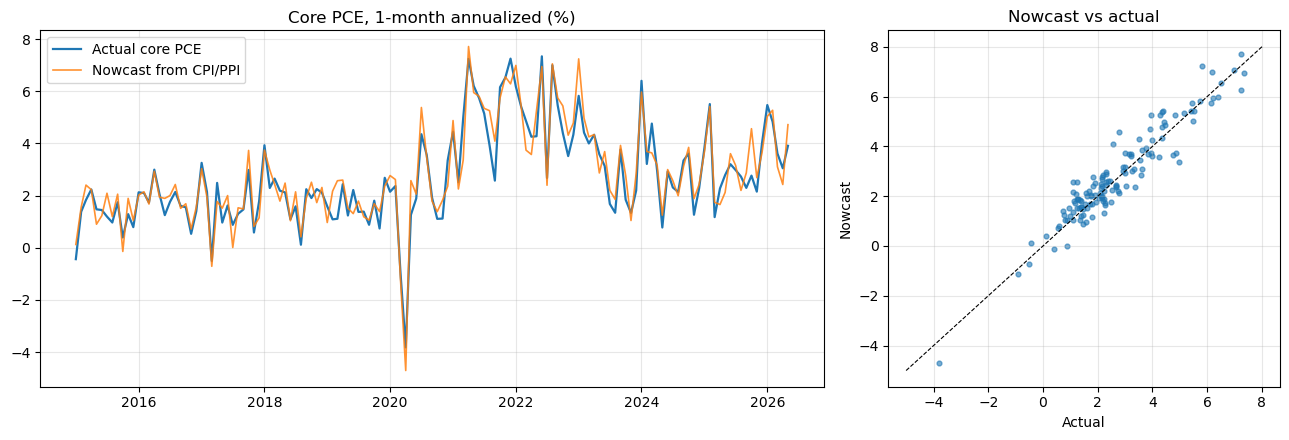

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), width_ratios=[2, 1])

ax = axes[0]
ax.plot(scored.index, scored["actual_ann"], label="Actual core PCE", lw=1.6)
ax.plot(scored.index, scored["nowcast_ann"], label="Nowcast from CPI/PPI",
        lw=1.2, alpha=0.85)
ax.set_title("Core PCE, 1-month annualized (%)")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
ax.scatter(scored["actual_ann"], scored["nowcast_ann"], s=12, alpha=0.6)
lims = [scored[["actual_ann", "nowcast_ann"]].min().min() - 0.3,
        scored[["actual_ann", "nowcast_ann"]].max().max() + 0.3]
ax.plot(lims, lims, "k--", lw=0.8)
ax.set_xlabel("Actual")
ax.set_ylabel("Nowcast")
ax.set_title("Nowcast vs actual")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 12. Component Diagnostics

Per-component fit of the nowcast against actual BEA changes (monthly %, x100),
weighted by average absolute core weight. The volatile imputed/financial lines that
the trimmed mean would discard dominate this list - they are the cost of nowcasting
core rather than the trimmed mean.

In [14]:
window = nowcast_chg.index.intersection(price_changes.index)
err100 = (nowcast_chg.loc[window] - price_changes.loc[window, core_lines]) * 100

diagnostics = pd.DataFrame({
    "source": {c: XWALK[c][0] for c in core_lines},
    "mean_weight": core_weights.loc[window].mean(),
    "rmse": np.sqrt((err100 ** 2).mean()),
    "corr": {c: nowcast_chg.loc[window, c].corr(price_changes.loc[window, c])
             for c in core_lines},
    "fb_share": from_fallback.loc[window].mean(),
})
diagnostics["w_rmse"] = diagnostics["rmse"] * diagnostics["mean_weight"].abs() * 100
diagnostics["description"] = descriptions.reindex(diagnostics.index).str.slice(0, 45)
diagnostics = diagnostics.sort_values("w_rmse", ascending=False)
diagnostics.head(25).round(3)

,source,mean_weight,rmse,corr,fb_share,w_rmse,description
342,NONE,0.034,0.630,0.282,1.000,2.140,Final consumption expenditures of nonprofit i
259,NONE,0.009,2.192,-0.260,1.000,1.885,Financial service charges and fees
335,NONE,0.004,3.277,-0.206,1.000,1.437,Passenger fares for foreign travel
184,PPI,0.058,0.245,0.533,0.000,1.421,Nonprofit hospitals' services to households
207,PPI,0.009,1.559,0.900,0.000,1.345,Air transportation (64)
339,NONE,-0.009,1.286,0.081,1.000,1.213,Foreign travel in the United States
255,NONE,0.013,0.858,0.576,1.000,1.080,Commercial banks
336,NONE,0.007,1.291,-0.196,1.000,0.902,U.S. travel outside the United States
299,CPI,0.008,1.034,0.338,0.292,0.872,Legal services
50,CPI,0.010,0.729,0.944,0.015,0.749,Computer software and accessories


## 13. Latest-Month Nowcast

The official core PCE index is extended beyond the latest PCE release with the
nowcast m/m changes (using the last available weights). The 1m/6m/12m rates below
are the headline numbers. When CPI leads PCE (mid-month to month-end), the target
month has no official value yet.

In [15]:
# official index levels extended with nowcast changes beyond the last PCE release
index = core_index.copy()
for t in nowcast_index[nowcast_index > core_index.index[-1]]:
    index.loc[t] = index.iloc[-1] * (1 + core_aggregate(nowcast_chg.loc[t],
                                                        core_weights.loc[last_bea]))
index = index.sort_index()

target = nowcast_index[-1]
rate_1m = 100 * ((index.loc[target] / index.shift(1).loc[target]) ** 12 - 1)
rate_6m = 100 * ((index.loc[target] / index.shift(6).loc[target]) ** 2 - 1)
rate_12m = 100 * (index.loc[target] / index.shift(12).loc[target] - 1)

print(f"Core PCE estimate for {target:%B %Y}"
      + ("  (official data not yet released)" if target > last_bea
         else "  (official data already published - shown for comparison)"))
print(f"  1-month annualized : {rate_1m:5.2f}%")
print(f"  6-month annualized : {rate_6m:5.2f}%")
print(f"  12-month           : {rate_12m:5.2f}%")
if target <= last_bea:
    print(f"  actual 1m annualized: {bt.loc[target, 'actual_ann']:.2f}%")
    print(f"  nowcast for same month from CPI/PPI only: {bt.loc[target, 'nowcast_ann']:.2f}%")

# largest-weight components and their estimated changes for the target month
detail = pd.DataFrame({
    "description": descriptions.reindex(core_lines).str.slice(0, 45),
    "source": {c: XWALK[c][0] for c in core_lines},
    "weight": core_weights.loc[last_bea],
    "est_monthly_pct": nowcast_chg.loc[target] * 100,
    "on_fallback": from_fallback.loc[target],
}).sort_values("weight", key=abs, ascending=False)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
bt.to_csv(OUTPUT_DIR / "core_nowcast_detailed_backtest.csv")
detail.to_csv(OUTPUT_DIR / "core_nowcast_detailed_components_latest.csv")
print(f"\nWrote {OUTPUT_DIR / 'core_nowcast_detailed_backtest.csv'}")
print(f"Wrote {OUTPUT_DIR / 'core_nowcast_detailed_components_latest.csv'}")
detail.head(15).round(4)

Core PCE estimate for May 2026  (official data already published - shown for comparison)
  1-month annualized :  3.91%
  6-month annualized :  4.14%
  12-month           :  3.41%
  actual 1m annualized: 3.91%
  nowcast for same month from CPI/PPI only: 4.72%

Wrote C:\Users\abour\OneDrive\Economic Research\Inflation\Trimmed Mean PCE Estimate\outputs\core_nowcast_detailed_backtest.csv
Wrote C:\Users\abour\OneDrive\Economic Research\Inflation\Trimmed Mean PCE Estimate\outputs\core_nowcast_detailed_components_latest.csv


,description,source,weight,est_monthly_pct,on_fallback
162,Owner-occupied stationary homes,CPI,0.1282,0.2968,False
184,Nonprofit hospitals' services to households,PPI,0.0582,0.4619,False
174,Physician services (44),PPI,0.0439,0.0319,False
156,Tenant-occupied stationary homes and landlord,CPI,0.0402,0.3619,False
342,Final consumption expenditures of nonprofit i,NONE,0.0343,0.2330,True
123,Prescription drugs,CPI,0.0312,-0.8997,False
242,Meals at limited service eating places,CPI,0.0283,0.3218,False
243,Meals at other eating places,CPI,0.0268,0.2960,False
268,Portfolio management and investment advice se,PPI,0.0187,4.8422,False
186,Government hospitals,PPI,0.0174,0.4619,False


## 14. History + Nowcast Comparison Table

One row per month from 2015 through the latest nowcast: estimated vs actual on a m/m,
1-month-annualized, and y/y basis. The y/y estimate applies each month's nowcast to
the official index history (chained through the extended index for months beyond the
latest PCE release, where the actual columns are blank). Full table saved to
`outputs/core_nowcast_detailed_vs_actual.csv`.

In [16]:
table = pd.DataFrame(index=bt.index)
table["mm_est"] = 100 * bt["nowcast"]
table["mm_act"] = (100 * actual_mm).reindex(bt.index)
table["ann_est"] = bt["nowcast_ann"]
table["ann_act"] = bt["actual_ann"]

yoy_est = {}
for t in bt.index:
    t1 = t - pd.DateOffset(months=1)
    t12 = t - pd.DateOffset(months=12)
    if t in core_index.index:
        yoy_est[t] = 100 * (core_index.loc[t1] * (1 + bt.loc[t, "nowcast"])
                            / core_index.loc[t12] - 1)
    else:
        yoy_est[t] = 100 * (index.loc[t] / index.loc[t12] - 1)
table["yoy_est"] = pd.Series(yoy_est)
table["yoy_act"] = (100 * (core_index / core_index.shift(12) - 1)).reindex(table.index)

table.round(3).to_csv(OUTPUT_DIR / "core_nowcast_detailed_vs_actual.csv")
print(f"Wrote {OUTPUT_DIR / 'core_nowcast_detailed_vs_actual.csv'} ({len(table)} months)")
table.tail(15).round(2)

Wrote C:\Users\abour\OneDrive\Economic Research\Inflation\Trimmed Mean PCE Estimate\outputs\core_nowcast_detailed_vs_actual.csv (137 months)


,mm_est,mm_act,ann_est,ann_act,yoy_est,yoy_act
date,,,,,,
2025-03-01,0.14,0.10,1.74,1.18,2.72,2.67
2025-04-01,0.14,0.19,1.66,2.27,2.56,2.61
2025-05-01,0.18,0.23,2.12,2.79,2.73,2.78
2025-06-01,0.30,0.26,3.61,3.20,2.84,2.81
2025-07-01,0.26,0.25,3.16,2.98,2.88,2.86
2025-08-01,0.18,0.22,2.20,2.73,2.87,2.91
2025-09-01,0.24,0.19,2.87,2.30,2.87,2.83
2025-10-01,0.37,0.23,4.57,2.77,2.90,2.75
2025-11-01,0.22,0.18,2.69,2.15,2.87,2.83


## 15. CPI-Only Nowcast (PPI growth carried forward)

A same-day-as-CPI variant, usable ~1 day before PPI prints: components whose BEA
deflator is a PPI (physicians, hospitals, nursing homes, airfares, insurance,
portfolio management/commissions) **repeat the prior month's m/m change**. CPI-mapped
components and the trailing-average fallback are unchanged (both available on CPI
day). Once PPI is released the next day, the full nowcast above supersedes this one.

In [17]:
nowcast_cpi = pd.DataFrame(index=nowcast_index, columns=core_lines, dtype=float)
for line in core_lines:
    src, ids = XWALK[line]
    if src == "CPI":
        total = sum(ids.values())
        nowcast_cpi[line] = sum(source_chg[sid].reindex(nowcast_index) * (w / total)
                                for sid, w in ids.items())
    elif src == "PPI":
        total = sum(ids.values())
        combo = sum(source_chg[sid] * (w / total) for sid, w in ids.items())
        nowcast_cpi[line] = combo.shift(1).reindex(nowcast_index)  # prior month's change
nowcast_cpi = nowcast_cpi.where(~nowcast_cpi.isna(), fallback[core_lines])

bt["nowcast_cpionly"] = [
    core_aggregate(nowcast_cpi.loc[t],
                   core_weights.loc[t - pd.DateOffset(months=1)]
                   if t - pd.DateOffset(months=1) in core_weights.index
                   else core_weights.loc[last_bea])
    for t in bt.index]
bt["nowcast_cpionly_ann"] = 100 * ((1 + bt["nowcast_cpionly"]) ** 12 - 1)

# extended index for y/y in months beyond the latest PCE release
index_cpi = core_index.copy()
for t in nowcast_index[nowcast_index > core_index.index[-1]]:
    index_cpi.loc[t] = index_cpi.iloc[-1] * (
        1 + core_aggregate(nowcast_cpi.loc[t], core_weights.loc[last_bea]))
index_cpi = index_cpi.sort_index()

yoy_cpi = {}
for t in bt.index:
    t1 = t - pd.DateOffset(months=1)
    t12 = t - pd.DateOffset(months=12)
    if t in core_index.index:
        yoy_cpi[t] = 100 * (core_index.loc[t1] * (1 + bt.loc[t, "nowcast_cpionly"])
                            / core_index.loc[t12] - 1)
    else:
        yoy_cpi[t] = 100 * (index_cpi.loc[t] / index_cpi.loc[t12] - 1)
table["mm_est_cpionly"] = 100 * bt["nowcast_cpionly"]
table["ann_est_cpionly"] = bt["nowcast_cpionly_ann"]
table["yoy_est_cpionly"] = pd.Series(yoy_cpi)
table.round(3).to_csv(OUTPUT_DIR / "core_nowcast_detailed_vs_actual.csv")

comp = {}
for col in ["nowcast_ann", "nowcast_cpionly_ann"]:
    err = (bt[col].reindex(scored.index) - scored["actual_ann"]).dropna()
    comp[col] = {"MAE": err.abs().mean(), "RMSE": np.sqrt((err ** 2).mean()),
                 "bias": err.mean(),
                 "corr": bt[col].reindex(scored.index).corr(scored["actual_ann"])}
print("CPI+PPI vs CPI-only, 1m annualized vs actual (pp):")
print(pd.DataFrame(comp).T.round(3))

print(f"\nCPI-only estimate for {target:%B %Y}: "
      f"1m annualized {bt.loc[target, 'nowcast_cpionly_ann']:.2f}%, "
      f"y/y {yoy_cpi[target]:.2f}%")
table.tail(15)[["mm_est", "mm_est_cpionly", "mm_act",
                "ann_est", "ann_est_cpionly", "ann_act",
                "yoy_est", "yoy_est_cpionly", "yoy_act"]].round(2)

CPI+PPI vs CPI-only, 1m annualized vs actual (pp):
                       MAE   RMSE   bias   corr
nowcast_ann          0.470  0.594  0.123  0.949
nowcast_cpionly_ann  0.891  1.152  0.110  0.804

CPI-only estimate for May 2026: 1m annualized 1.89%, y/y 3.24%


,mm_est,mm_est_cpionly,mm_act,ann_est,ann_est_cpionly,ann_act,yoy_est,yoy_est_cpionly,yoy_act
date,,,,,,,,,
2025-03-01,0.14,0.29,0.10,1.74,3.55,1.18,2.72,2.87,2.67
2025-04-01,0.14,0.30,0.19,1.66,3.62,2.27,2.56,2.73,2.61
2025-05-01,0.18,0.09,0.23,2.12,1.03,2.79,2.73,2.64,2.78
2025-06-01,0.30,0.25,0.26,3.61,3.01,3.20,2.84,2.79,2.81
2025-07-01,0.26,0.17,0.25,3.16,2.06,2.98,2.88,2.79,2.86
2025-08-01,0.18,0.26,0.22,2.20,3.17,2.73,2.87,2.95,2.91
2025-09-01,0.24,0.21,0.19,2.87,2.61,2.30,2.87,2.85,2.83
2025-10-01,0.37,0.27,0.23,4.57,3.30,2.77,2.90,2.80,2.75
2025-11-01,0.22,0.34,0.18,2.69,4.18,2.15,2.87,3.00,2.83


## 16. Group Nowcasts: Core Goods, Housing, Core Services ex Housing, Headline

The component-level nowcasts aggregate to any grouping. This section adds the
non-core components (food and energy, mapped by the same crosswalk) so the full
partition is estimated, then builds the standard decomposition:

- **core goods** - goods excluding food and energy goods
- **housing** - tenant rent, owner-occupied imputed rent, farm dwellings, group
  housing (utilities are not housing)
- **core services ex housing** - the Fed's "supercore"
- **core PCE** and **headline PCE**

Each group uses its own renormalized weights (prior month's for the nowcast).
"Actual" for the groups is the replication (actual BEA component changes,
same-month weights) - essentially exact, and the only option for groups BEA does
not publish; core and headline are additionally scored against the official FRED
indexes. Full history saved to `outputs/core_nowcast_detailed_groups.csv`.

In [18]:
# nowcast the food & energy components so goods/headline groups are complete
extra_lines = [L for L in partition if L not in core_lines]
extra_series = sorted({sid for L in extra_lines for sid in XWALK[L][1]}
                      - set(source_levels.columns))
extra_levels, extra_missing = bls_fetch(extra_series, SOURCE_START_YEAR, date.today().year)
for sid in list(extra_missing):
    try:
        s = fred_fetch(sid)
        if len(s):
            extra_levels[sid] = s
            extra_missing.remove(sid)
    except Exception:
        pass
print(f"pulled {extra_levels.shape[1]} of {len(extra_series)} food/energy series"
      + (f"; missing -> fallback: {extra_missing}" if extra_missing else ""))

extra_chg = extra_levels.sort_index().pct_change(fill_method=None)
cuur_extra = [c for c in extra_chg.columns if c.startswith("CUUR")]
if CRUDE_SA and cuur_extra:
    raw = extra_chg[cuur_extra]
    seasonal = raw.groupby(raw.index.month).transform(
        lambda x: x.shift(1).rolling(5, min_periods=3).mean())
    average = raw.shift(1).rolling(60, min_periods=36).mean()
    adjusted = raw - seasonal + average
    extra_chg[cuur_extra] = adjusted.where(adjusted.notna(), raw)
src_all = pd.concat([source_chg, extra_chg], axis=1)

nowcast_extra = pd.DataFrame(index=nowcast_index, columns=extra_lines, dtype=float)
for line in extra_lines:
    src, ids = XWALK[line]
    if src == "NONE":
        continue
    total = sum(ids.values())
    nowcast_extra[line] = sum(src_all[sid].reindex(nowcast_index) * (w / total)
                              for sid, w in ids.items())
nowcast_extra = nowcast_extra.where(~nowcast_extra.isna(), fallback[extra_lines])
nowcast_all = pd.concat([nowcast_chg, nowcast_extra], axis=1)[partition]

# group memberships from the hierarchy
GOODS_ROOT, SERVICES_ROOT = 2, 150
housing_root = parent[154]  # "Housing" = parent of tenant-rent line 154


def under(root):
    return [L for L in partition if L == root or root in ancestors(L)]


housing_set = set(under(housing_root))
GROUPS = {
    "core_goods": [L for L in under(GOODS_ROOT) if L not in core_excl],
    "housing": sorted(housing_set),
    "core_serv_xhous": [L for L in under(SERVICES_ROOT)
                        if L not in core_excl and L not in housing_set],
    "core_pce": core_lines,
    "headline_pce": partition,
}
assert sorted(under(GOODS_ROOT) + under(SERVICES_ROOT)) == sorted(partition)
for g, members in GROUPS.items():
    share = weights[members].iloc[-1].sum()
    print(f"{g:16s} {len(members):3d} components, {100 * share:5.1f}% of PCE weight")

pulled 27 of 27 food/energy series
core_goods        69 components,  21.7% of PCE weight
housing            6 components,  15.6% of PCE weight
core_serv_xhous  116 components,  51.5% of PCE weight
core_pce         191 components,  88.9% of PCE weight
headline_pce     219 components, 100.0% of PCE weight


In [19]:
group_table = pd.DataFrame(index=[t for t in nowcast_index
                                  if t - pd.DateOffset(months=1) in weights.index])
group_metrics = {}
for g, members in GROUPS.items():
    w = weights[members]
    wn = w.div(w.sum(axis=1), axis=0)
    est = pd.Series({t: (nowcast_all.loc[t, members] * wn.loc[t - pd.DateOffset(months=1)]).sum()
                     for t in group_table.index})
    rep = pd.Series({t: (price_changes.loc[t, members] * wn.loc[t]).sum()
                     for t in price_changes.index})

    idx_rep = pd.concat([pd.Series([100.0], index=[rep.index[0] - pd.DateOffset(months=1)]),
                         100.0 * (1.0 + rep).cumprod()]).sort_index()
    idx_ext = idx_rep.copy()
    for t in nowcast_index[nowcast_index > last_bea]:
        idx_ext.loc[t] = idx_ext.iloc[-1] * (1 + est[t])
    idx_ext = idx_ext.sort_index()

    group_table[g + "_mm_est"] = 100 * est
    group_table[g + "_mm_act"] = (100 * rep).reindex(group_table.index)
    group_table[g + "_ann_est"] = 100 * ((1 + est) ** 12 - 1)
    group_table[g + "_ann_act"] = (100 * ((1 + rep) ** 12 - 1)).reindex(group_table.index)
    yoy_est, yoy_act = {}, {}
    for t in group_table.index:
        t1, t12 = t - pd.DateOffset(months=1), t - pd.DateOffset(months=12)
        if t <= last_bea:
            yoy_est[t] = 100 * (idx_rep.loc[t1] * (1 + est[t]) / idx_rep.loc[t12] - 1)
            yoy_act[t] = 100 * (idx_rep.loc[t] / idx_rep.loc[t12] - 1)
        else:
            yoy_est[t] = 100 * (idx_ext.loc[t] / idx_ext.loc[t12] - 1)
    group_table[g + "_yoy_est"] = pd.Series(yoy_est)
    group_table[g + "_yoy_act"] = pd.Series(yoy_act)

    err = (group_table[g + "_ann_est"] - group_table[g + "_ann_act"]).loc[:last_bea].dropna()
    group_metrics[g] = {"MAE": err.abs().mean(), "RMSE": np.sqrt((err ** 2).mean()),
                        "bias": err.mean(),
                        "corr": group_table[g + "_ann_est"].corr(group_table[g + "_ann_act"])}

print("nowcast vs replication ('actual'), 1m annualized (pp), 2015-01 .. %s:" % f"{last_bea:%Y-%m}")
print(pd.DataFrame(group_metrics).T.round(3))

# cross-checks against official indexes
headline_index = fred_fetch("PCEPI", start="2013-01-01")
for g, official in [("core_pce", core_index), ("headline_pce", headline_index)]:
    off_ann = (100 * ((1 + official.pct_change()) ** 12 - 1)).reindex(group_table.index)
    err = (group_table[g + "_ann_est"] - off_ann).dropna()
    print(f"\n{g} vs official index: MAE={err.abs().mean():.3f} bias={err.mean():+.3f}")

print(f"\n=== Estimates for {target:%B %Y} ===")
summary = pd.DataFrame({
    "m/m (est)": {g: group_table.loc[target, g + "_mm_est"] for g in GROUPS},
    "m/m (act)": {g: group_table.loc[target, g + "_mm_act"] for g in GROUPS},
    "1m annualized (est)": {g: group_table.loc[target, g + "_ann_est"] for g in GROUPS},
    "1m annualized (act)": {g: group_table.loc[target, g + "_ann_act"] for g in GROUPS},
    "y/y (est)": {g: group_table.loc[target, g + "_yoy_est"] for g in GROUPS},
    "y/y (act)": {g: group_table.loc[target, g + "_yoy_act"] for g in GROUPS},
})
print(summary.round(2).to_string())

group_table.round(3).to_csv(OUTPUT_DIR / "core_nowcast_detailed_groups.csv")
print(f"\nWrote {OUTPUT_DIR / 'core_nowcast_detailed_groups.csv'} ({len(group_table)} months)")
group_table.tail(13)[[c for c in group_table.columns if "ann" in c]].round(2)

nowcast vs replication ('actual'), 1m annualized (pp), 2015-01 .. 2026-05:
                   MAE   RMSE   bias   corr
core_goods       0.693  0.886  0.093  0.972
housing          0.095  0.217  0.019  0.992
core_serv_xhous  0.826  1.059  0.121  0.857
core_pce         0.469  0.596  0.096  0.948
headline_pce     0.464  0.593  0.062  0.974



core_pce vs official index: MAE=0.470 bias=+0.123

headline_pce vs official index: MAE=0.463 bias=+0.096

=== Estimates for May 2026 ===
                 m/m (est)  m/m (act)  1m annualized (est)  1m annualized (act)  y/y (est)  y/y (act)
core_goods           -0.05      -0.10                -0.62                -1.19       2.51       2.46
housing               0.31       0.31                 3.81                 3.75       3.24       3.23
core_serv_xhous       0.59       0.50                 7.33                 6.17       3.98       3.89
core_pce              0.38       0.32                 4.72                 3.91       3.49       3.42
headline_pce          0.51       0.45                 6.31                 5.53       4.15       4.08

Wrote C:\Users\abour\OneDrive\Economic Research\Inflation\Trimmed Mean PCE Estimate\outputs\core_nowcast_detailed_groups.csv (137 months)


,core_goods_ann_est,core_goods_ann_act,housing_ann_est,housing_ann_act,core_serv_xhous_ann_est,core_serv_xhous_ann_act,core_pce_ann_est,core_pce_ann_act,headline_pce_ann_est,headline_pce_ann_act
2025-05-01,2.77,2.97,3.27,3.16,1.50,2.58,2.12,2.78,1.72,2.18
2025-06-01,4.80,4.81,3.51,3.46,3.14,2.46,3.61,3.21,3.56,3.49
2025-07-01,-0.65,0.04,3.25,3.32,4.78,4.20,3.16,3.01,2.55,2.11
2025-08-01,-1.70,-1.30,3.96,4.43,3.36,3.99,2.20,2.75,2.68,3.21
2025-09-01,2.62,2.15,2.09,1.82,3.22,2.52,2.87,2.31,3.57,3.19
2025-10-01,2.65,-0.06,3.41,1.73,5.74,4.27,4.57,2.75,3.99,2.33
2025-11-01,1.72,-0.26,2.98,1.74,3.01,3.30,2.69,2.15,3.23,2.67
2025-12-01,6.52,5.32,3.70,3.67,2.42,3.54,3.63,3.99,3.76,4.04
2026-01-01,2.31,3.68,2.75,2.74,6.90,7.12,5.04,5.50,3.91,4.29
2026-02-01,8.70,10.60,2.46,2.45,4.74,3.29,5.27,4.86,5.39,4.94


## 17. Component-Level Output (m/m and y/y, full history)

One row per month per component (all 219 partition lines, 2015 - latest nowcast):
estimated and actual m/m change, and estimated and actual y/y change. The y/y
estimate chains each component's own BEA price index through the prior month with
the estimated m/m change (months beyond the latest PCE release chain on the
extended index; their actual columns are blank). Saved to
`outputs/core_nowcast_detailed_components_history.csv`.

In [20]:
# per-component price indexes, extended beyond the last PCE release with estimates
pidx = prices.copy()
for t in nowcast_index[nowcast_index > last_bea]:
    pidx.loc[t] = pidx.loc[t - pd.DateOffset(months=1)] * (1 + nowcast_all.loc[t])
pidx = pidx.sort_index()

mm_est = nowcast_all.reindex(nowcast_index)
yoy_est = (pidx.shift(1).reindex(nowcast_index) * (1 + mm_est)
           / pidx.shift(12).reindex(nowcast_index) - 1)
mm_act = price_changes.reindex(nowcast_index)
yoy_act = (prices / prices.shift(12) - 1).reindex(nowcast_index)
w_hist = weights.reindex(nowcast_index).ffill()

comp_hist = pd.DataFrame({
    "weight": w_hist.stack(),
    "mm_est": (100 * mm_est).stack(),
    "mm_act": (100 * mm_act).stack(),
    "yoy_est": (100 * yoy_est).stack(),
    "yoy_act": (100 * yoy_act).stack(),
})
comp_hist.index.names = ["date", "line"]
comp_hist = comp_hist.reset_index()
comp_hist["description"] = comp_hist["line"].map(descriptions.str.slice(0, 45))
comp_hist["source"] = comp_hist["line"].map({c: XWALK[c][0] for c in partition})
comp_hist = comp_hist[["date", "line", "description", "source", "weight",
                       "mm_est", "mm_act", "yoy_est", "yoy_act"]]
comp_hist.round(4).to_csv(OUTPUT_DIR / "core_nowcast_detailed_components_history.csv",
                          index=False)
print(f"Wrote {OUTPUT_DIR / 'core_nowcast_detailed_components_history.csv'} "
      f"({len(comp_hist):,} rows = {mm_est.shape[0]} months x {mm_est.shape[1]} components)")

# largest components for the target month
latest = (comp_hist[comp_hist["date"] == target]
          .sort_values("weight", key=abs, ascending=False)
          .set_index("line").drop(columns="date"))
latest.head(20).round(3)

Wrote C:\Users\abour\OneDrive\Economic Research\Inflation\Trimmed Mean PCE Estimate\outputs\core_nowcast_detailed_components_history.csv (30,003 rows = 137 months x 219 components)


,description,source,weight,mm_est,mm_act,yoy_est,yoy_act
line,,,,,,,
162,Owner-occupied stationary homes,CPI,0.114,0.297,0.291,3.331,3.325
184,Nonprofit hospitals' services to households,PPI,0.052,0.462,0.385,3.331,3.252
174,Physician services (44),PPI,0.039,0.032,0.143,1.288,1.401
156,Tenant-occupied stationary homes and landlord,CPI,0.036,0.362,0.362,2.940,2.940
342,Final consumption expenditures of nonprofit i,NONE,0.030,0.233,-0.856,1.406,0.304
123,Prescription drugs,CPI,0.028,-0.900,-0.900,-2.018,-2.018
242,Meals at limited service eating places,CPI,0.025,0.322,0.318,3.267,3.263
243,Meals at other eating places,CPI,0.024,0.296,0.296,3.800,3.800
115,Gasoline and other motor fuel,CPI,0.022,7.045,6.842,42.115,41.846


## Caveats

- **Partition is data-dependent**: it is re-derived on every run from BEA data
  coverage. BEA's annual updates (each fall) can shift which level of detail is
  usable; the coverage printout in section 4 should always read ~100%.
- **Core is harder to nowcast than the trimmed mean**: the trim drops outlier
  components into the tails; core keeps everything. The dominant error sources are
  portfolio management/commissions (equity-market-driven), NPISH (imputed, fallback
  only), airfares, and net foreign travel.
- **Vintage**: CPI/PPI and BEA inputs are current-vintage (revised). Real-time
  accuracy will be modestly worse than the backtest.
- **Seasonal adjustment**: health/air PPIs use BLS-published SA variants; other PPIs
  are raw (BLS found no stable seasonality); NSA CPI items use a crude own-history
  adjustment. This scheme backtested best (MAE 0.47 vs 0.52 crude-everything and
  0.63 raw-everything), but BEA's internal factors still differ.
- **Insurance and financial services**: the detail split helps (premiums map to PPIs,
  normal losses ride the fallback), but these remain net/imputed concepts. BEA's 2026
  annual update replaces the portfolio-management PPI deflator with quantity
  extrapolation - watch lines 268/269 diagnostics afterwards.
- Compared with `core_pce_nowcast.ipynb` (150 trimmed-mean components): replication
  error falls from ~0.14 to ~0.03pp and nowcast MAE from ~0.61 to ~0.47pp, from
  exact coverage, the financial/insurance/communication splits, and the published-SA
  PPI swaps.